In [80]:
import numpy as np
import pandas as pd
df=pd.read_csv('D:/Data science/khan/ML/New folder/homeprices_banglore.csv')
df.head()

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [81]:
from sklearn.preprocessing import MinMaxScaler
Scaler=MinMaxScaler()
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
x=df[['area','bedrooms']]
y=df['price']
x_scaled=X_scaler.fit_transform(x)

In [82]:
y_scaled = y_scaler.fit_transform(
    y.values.reshape(-1,1))

In [83]:
def Batch_gradient_descent(x,y,epochs,learning_rate=0.01):
    number_of_features=x.shape[1]
    w=np.ones(shape=(number_of_features))
    bias=0
    total=x.shape[0]

    cost_list=[]
    epochs_list=[]
    for i in range(epochs):
        y_pred=np.dot(w,x.T)+bias
        w_grad=-(2/total)*(x.T.dot(y-y_pred))
        bias_grad=-(2/total)*np.sum(y-y_pred)
        w=w-learning_rate*w_grad
        bias=bias-learning_rate*bias_grad
        cost=np.mean(np.square(y-y_pred))

        if(i%10==0):
            cost_list.append(cost)
            epochs_list.append(i)
    return w,bias,cost,cost_list,epochs_list

w,bias,cost,cost_list,epochs_list=Batch_gradient_descent(x_scaled,y_scaled.reshape(y_scaled.shape[0]),5000)
w,bias,cost


(array([0.75542854, 0.41583882]),
 np.float64(-0.11684836015389075),
 np.float64(0.0034259177049509168))

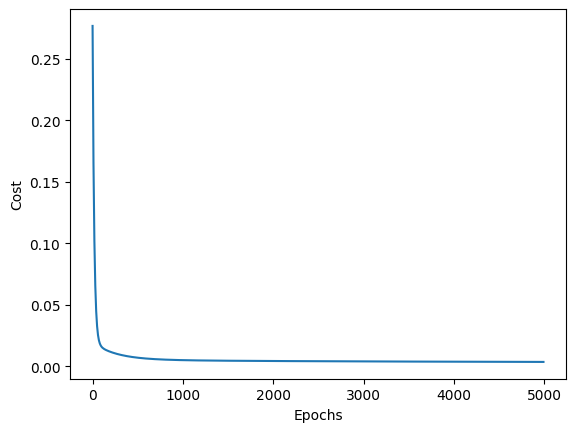

In [84]:
import matplotlib.pyplot as plt
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.plot(epochs_list,cost_list)

In [85]:
def predict(area,bedrooms,w,b):
    x_scaled=X_scaler.transform([[area,bedrooms]])[0]
    # scaled_price=w[0]*x_scaled[0]+w[1]*x_scaled[1]+b
    scaled_price = np.dot(x_scaled, w) + b
    real_price = y_scaler.inverse_transform(
        scaled_price.reshape(-1,1))
    return real_price[0][0]

In [86]:
predict(2600,4,w,bias)


c:\Users\Farhan Khan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(121.62885338709971)

In [96]:
import random
def Stochastic_gradient_descent(x,y,epochs,learning_rate=0.01):
    number_of_features=x.shape[1]
    w=np.ones(shape=(number_of_features))
    bias=0
    total=x.shape[0]

    cost_list=[]
    epochs_list=[]
    for i in range(epochs):
        random_index=random.randint(0,total-1)
        sample_x=x[random_index]
        sample_y=y[random_index]

        y_pred=np.dot(sample_x,w)+bias
        w_grad=-2*(sample_y-y_pred)
        bias_grad=-2*(sample_y-y_pred)
        w=w-learning_rate*w_grad
        bias=bias-learning_rate*bias_grad
        cost=np.square(sample_y-y_pred)

        if(i%10==0):
            cost_list.append(cost)
            epochs_list.append(i)
    return w,bias,cost,cost_list,epochs_list

w_a,bias_a,cost_a,cost_list_a,epochs_list_a=Stochastic_gradient_descent(x_scaled,y_scaled.reshape(y_scaled.shape[0]),5000)
w_a,bias_a,cost_a


(array([0.74511432, 0.74511432]),
 np.float64(-0.2548856815189712),
 np.float64(0.00034205764116870986))

In [97]:
w,bias,cost

(array([0.75542854, 0.41583882]),
 np.float64(-0.11684836015389075),
 np.float64(0.0034259177049509168))

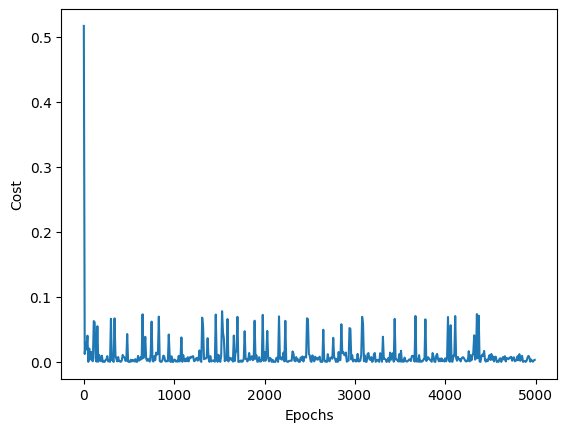

In [98]:
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.plot(epochs_list_a,cost_list_a)

In [99]:
def mini_batch_gradient_descent(x, y, epochs, batch_size, learning_rate=0.01):

    number_of_features = x.shape[1]

    # initialize weights and bias
    w = np.ones(shape=(number_of_features))
    bias = 0

    total_samples = x.shape[0]

    cost_list = []
    epoch_list = []

    for epoch in range(epochs):

        # shuffle data
        indices = np.random.permutation(total_samples)
        x_shuffled = x[indices]
        y_shuffled = y[indices]

        # create mini batches
        for i in range(0, total_samples, batch_size):

            x_batch = x_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # predictions
            y_pred = np.dot(x_batch, w) + bias

            # error
            error = y_batch - y_pred

            # gradients
            w_grad = -(2/len(x_batch)) * np.dot(x_batch.T, error)
            bias_grad = -(2/len(x_batch)) * np.sum(error)

            # update weights
            w = w - learning_rate * w_grad
            bias = bias - learning_rate * bias_grad

        # cost after each epoch
        cost = np.mean(np.square(y - (np.dot(x, w) + bias)))

        if epoch % 10 == 0:
            cost_list.append(cost)
            epoch_list.append(epoch)

            print(f"Epoch {epoch}, Cost: {cost}")

    return w, bias, cost_list, epoch_list

In [101]:
w_m, bias_m, cost_list_m, epoch_list_m = mini_batch_gradient_descent(
    x_scaled,
    y_scaled.reshape(y_scaled.shape[0]),
    epochs=100,
    batch_size=32,
    learning_rate=0.01
)
w, bias,cost

Epoch 0, Cost: 0.26276673457254596
Epoch 10, Cost: 0.15766501024727825
Epoch 20, Cost: 0.09750510556972952
Epoch 30, Cost: 0.0629845575622148
Epoch 40, Cost: 0.04309454988915444
Epoch 50, Cost: 0.03155627438599145
Epoch 60, Cost: 0.02478853208737036
Epoch 70, Cost: 0.020748623996523288
Epoch 80, Cost: 0.01827129260602433
Epoch 90, Cost: 0.016691709532086003


(array([0.82015506, 0.78816915]),
 np.float64(-0.3027445983749067),
 np.float64(0.0034259177049509168))

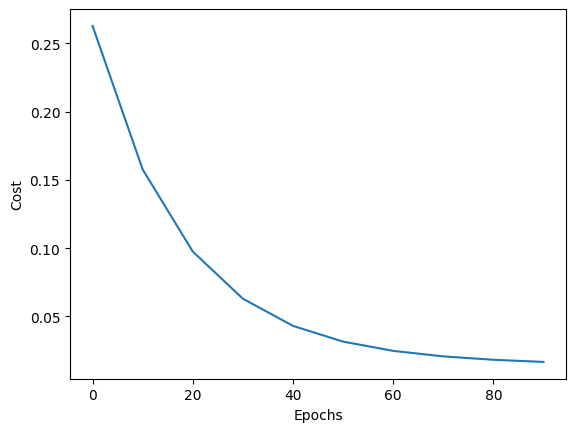

In [102]:
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.plot(epoch_list_m,cost_list_m)